In [1]:
!nvidia-smi

Tue Sep 22 07:29:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.5 MB/s eta 0:00:00


In [3]:
import ultralytics

print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
8.4.158


In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.6 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8R5eNs5U7dPKjCG1yMSe")
project = rf.workspace("sapna-kumari-wmcy5").project("smart-pothole-detection-due2d-342iz")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to smart-pothole-detection-1 in yolov8:: 100%|██████████| 6767/6767 [00:01<00:00, 5909.42it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
print(dataset.location)

/content/smart-pothole-detection-1


In [4]:
print(open("/content/smart-pothole-detection-1/data.yaml").read())

names:
- pothole
nc: 1
roboflow:
  license: Public Domain
  project: smart-pothole-detection-due2d-342iz
  url: https://universe.roboflow.com/sapna-kumari-wmcy5/smart-pothole-detection-due2d-342iz/dataset/1
  version: 1
  workspace: sapna-kumari-wmcy5
test: ../test/images
train: ../train/images
val: ../valid/images



In [5]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU: Tesla T4


In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

In [7]:
results = model.train(
    data="/content/smart-pothole-detection-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    pretrained=False,
    device=0
)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smart-pothole-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, ops

In [8]:
metrics = model.val()

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1306.6±578.1 MB/s, size: 86.7 KB)
val: Scanning /content/smart-pothole-detection-1/valid/labels.cache... 617 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 136.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 5.0it/s 7.9s
                   all        617       1845      0.781      0.622      0.717      0.428
Speed: 1.4ms preprocess, 4.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val


In [9]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.7812743830879131
Recall: 0.6222222222222222
mAP50: 0.716599290343928
mAP50-95: 0.4275915419477472


In [10]:
results = model.predict(
    source="/content/smart-pothole-detection-1/test/images",
    conf=0.25,
    save=True
)


image 1/178 /content/smart-pothole-detection-1/test/images/img-104_jpg.rf.8d62a938d5e0943bb143acd8b3488581.jpg: 640x640 2 potholes, 7.2ms
image 2/178 /content/smart-pothole-detection-1/test/images/img-111_jpg.rf.42c8e2543fe58f18a99c350470499aa3.jpg: 640x640 4 potholes, 7.3ms
image 3/178 /content/smart-pothole-detection-1/test/images/img-124_jpg.rf.6bc370793255e5f249df70adb62b59d9.jpg: 640x640 2 potholes, 7.2ms
image 4/178 /content/smart-pothole-detection-1/test/images/img-125_jpg.rf.148f6e8a367a4a6ef2ee238023caa678.jpg: 640x640 1 pothole, 7.2ms
image 5/178 /content/smart-pothole-detection-1/test/images/img-130_jpg.rf.d4a8b47a206b629493c8dfc8d591e3fd.jpg: 640x640 3 potholes, 7.2ms
image 6/178 /content/smart-pothole-detection-1/test/images/img-137_jpg.rf.e3c4c4532158578fe699dc9e1b8cfa66.jpg: 640x640 1 pothole, 8.2ms
image 7/178 /content/smart-pothole-detection-1/test/images/img-138_jpg.rf.9f8f5149b1bfd76c2c98ee07dc4fb918.jpg: 640x640 1 pothole, 7.2ms
image 8/178 /content/smart-pothole-d

Predicted images: 178


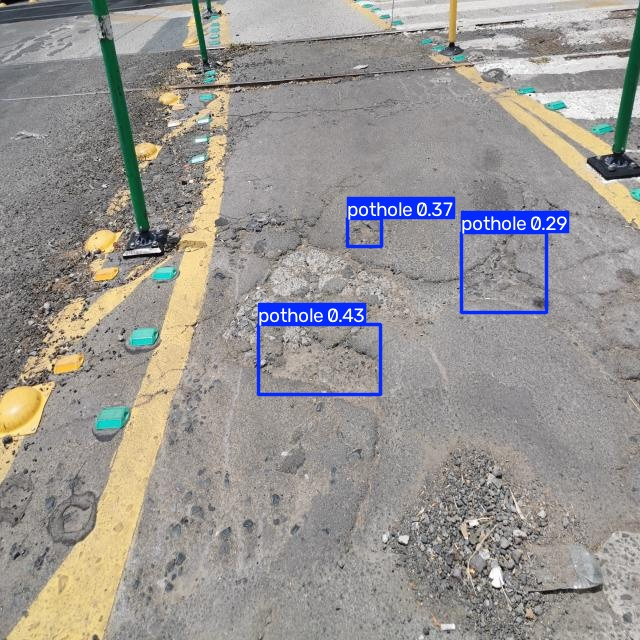

In [11]:
import glob
from IPython.display import Image, display

images = glob.glob("runs/detect/predict/*.jpg")

print("Predicted images:", len(images))

display(Image(filename=images[0]))

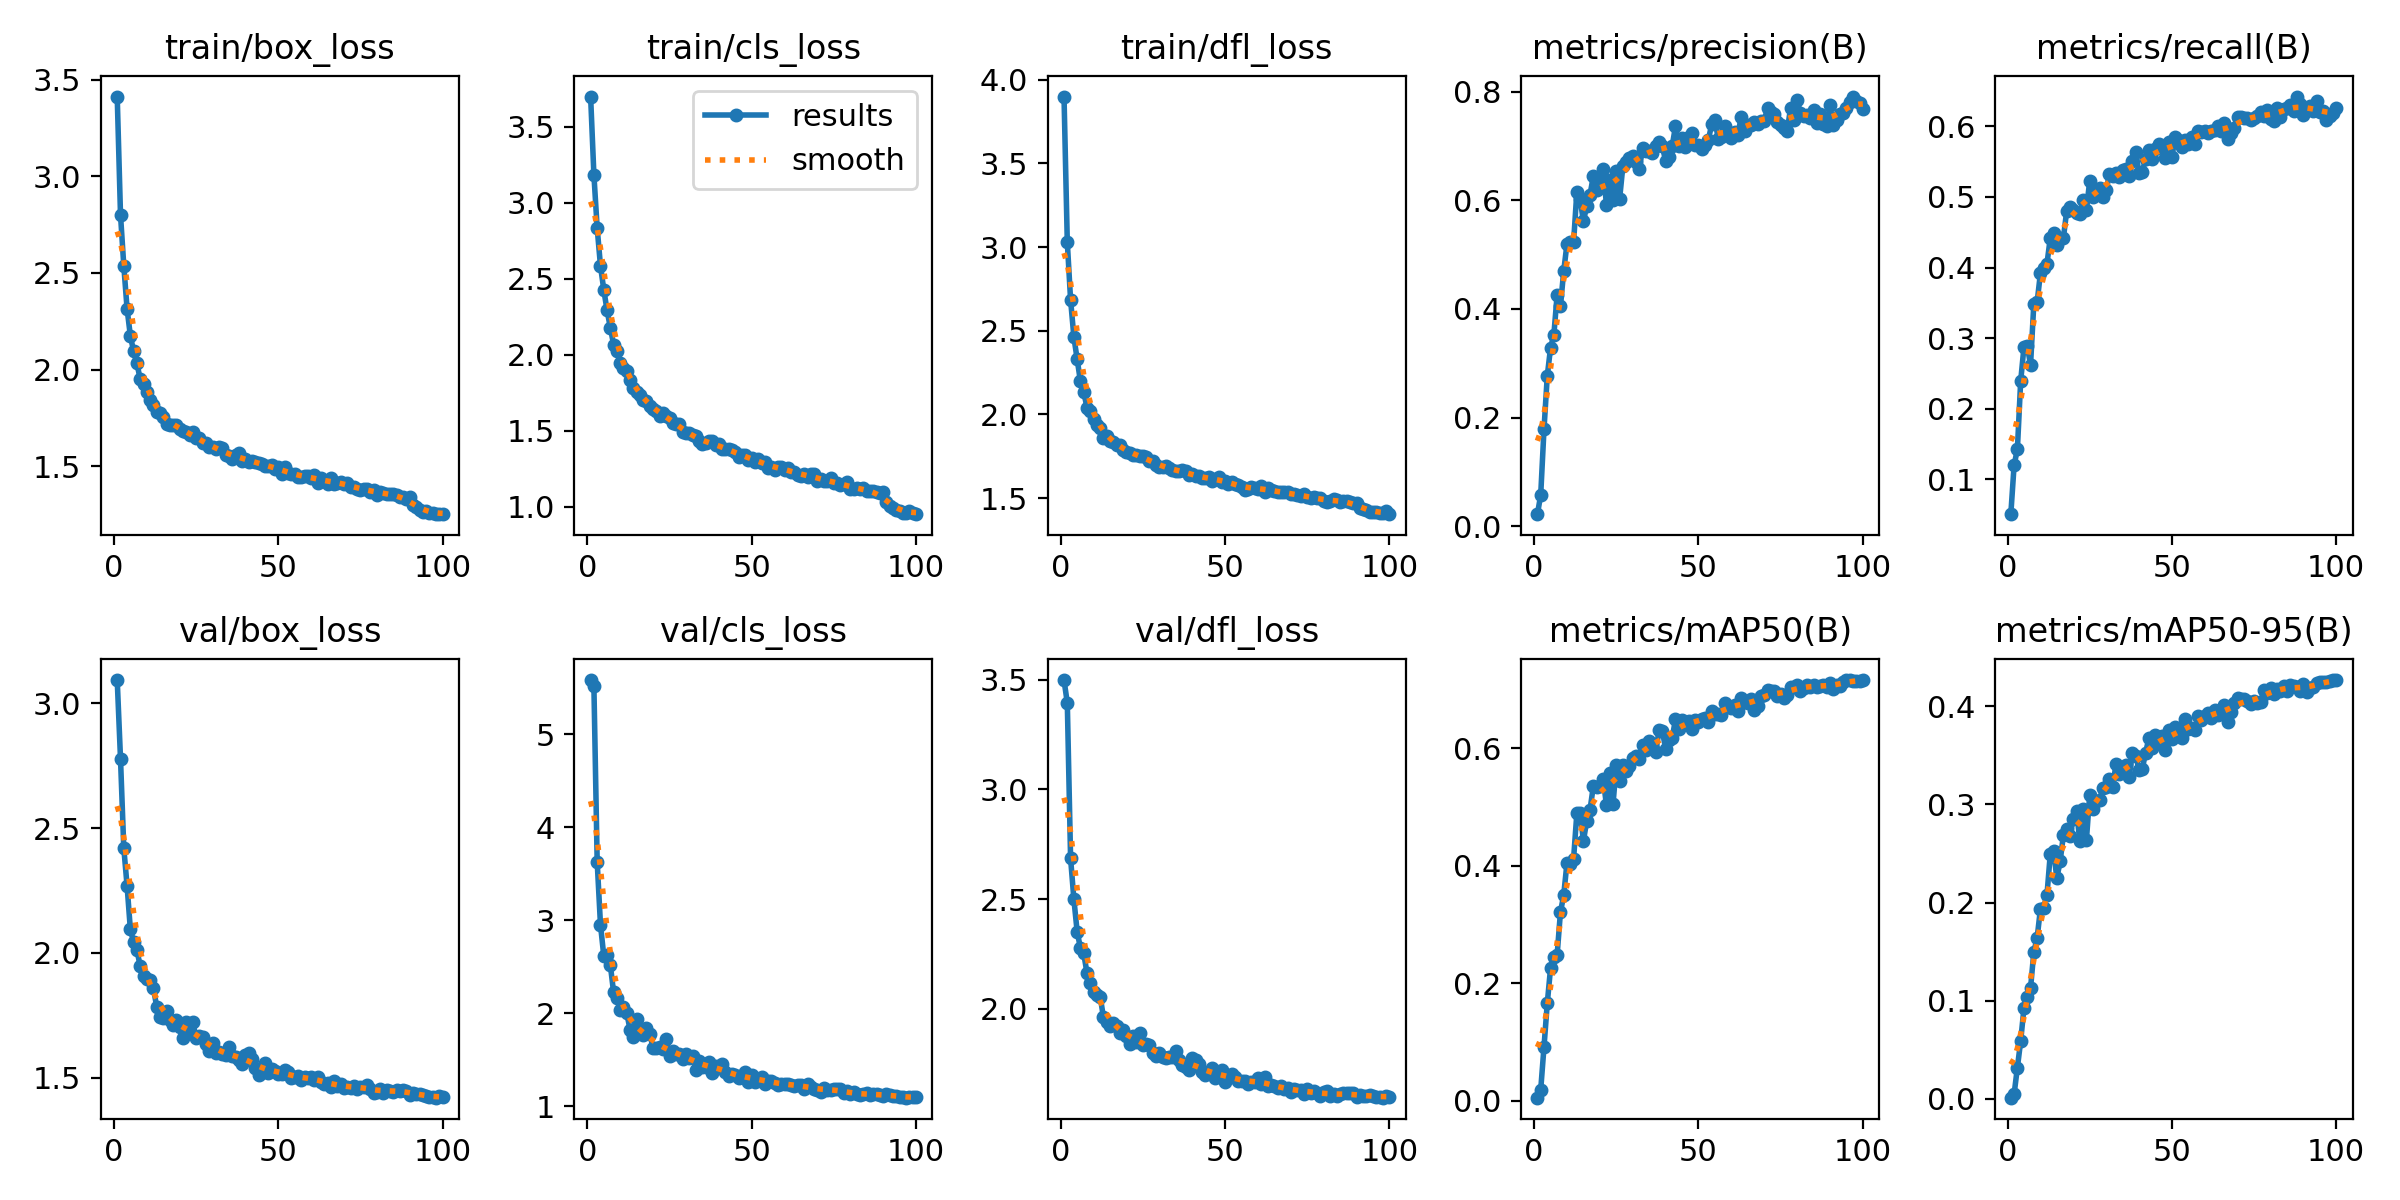

In [12]:
from IPython.display import Image, display

display(Image(filename="runs/detect/train/results.png"))

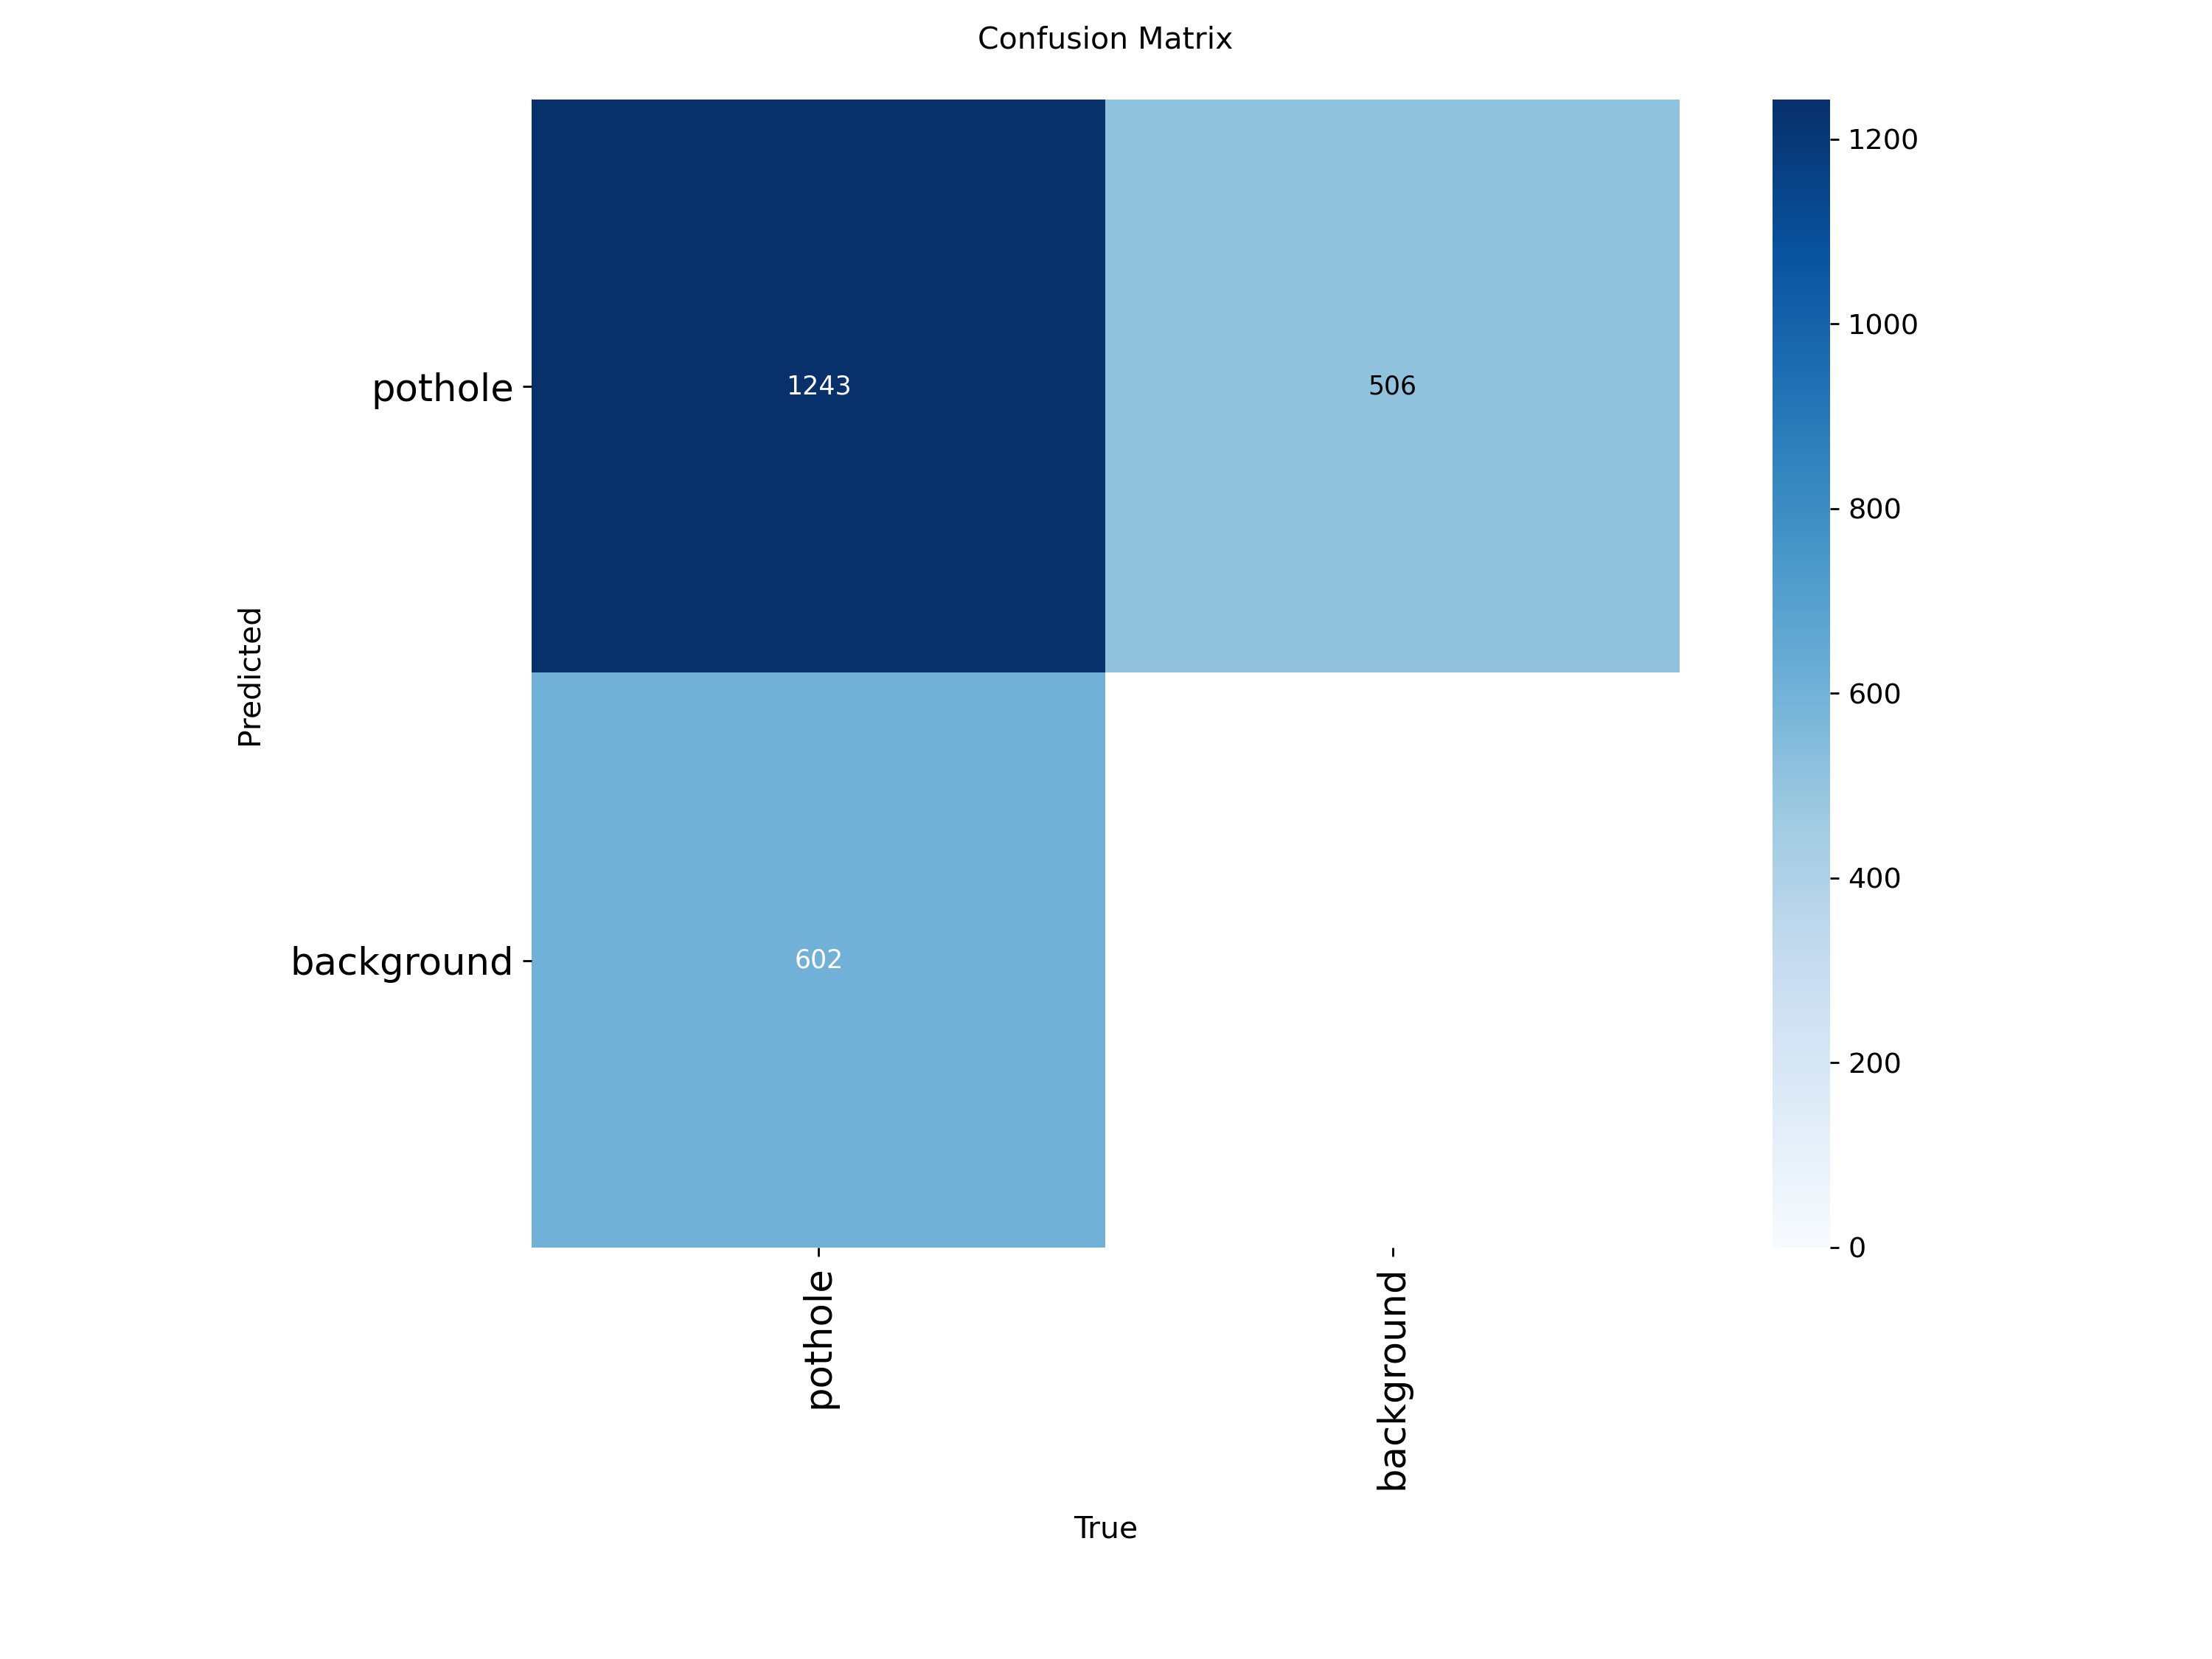

In [13]:
from IPython.display import Image, display

display(Image(filename="runs/detect/train/confusion_matrix.png"))

In [14]:
!cp runs/detect/train/weights/best.pt /content/pothole_yolov8_best.pt

In [15]:
from google.colab import files
files.download("/content/pothole_yolov8_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
metrics = model.val(conf=0.15)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1902.8±532.1 MB/s, size: 82.4 KB)
val: Scanning /content/smart-pothole-detection-1/valid/labels.cache... 617 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 123.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.7it/s 8.3s
                   all        617       1845      0.781      0.622      0.658      0.401
Speed: 2.4ms preprocess, 4.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2


In [17]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.7812743830879131
Recall: 0.6222222222222222
mAP50: 0.6575197346303292
mAP50-95: 0.4010485420461755


In [18]:
metrics = model.val(
    plots=True,
    save_json=True
)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2685.3±893.7 MB/s, size: 83.0 KB)
val: Scanning /content/smart-pothole-detection-1/valid/labels.cache... 617 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 215.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.0it/s 9.6s
                   all        617       1845      0.781      0.622      0.717      0.428
Speed: 1.7ms preprocess, 3.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Saving /content/runs/detect/val-3/predictions.json...

Evaluating faster-coco-eval mAP...
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 245ms
Prepared 1 package in 25ms
Installed 1

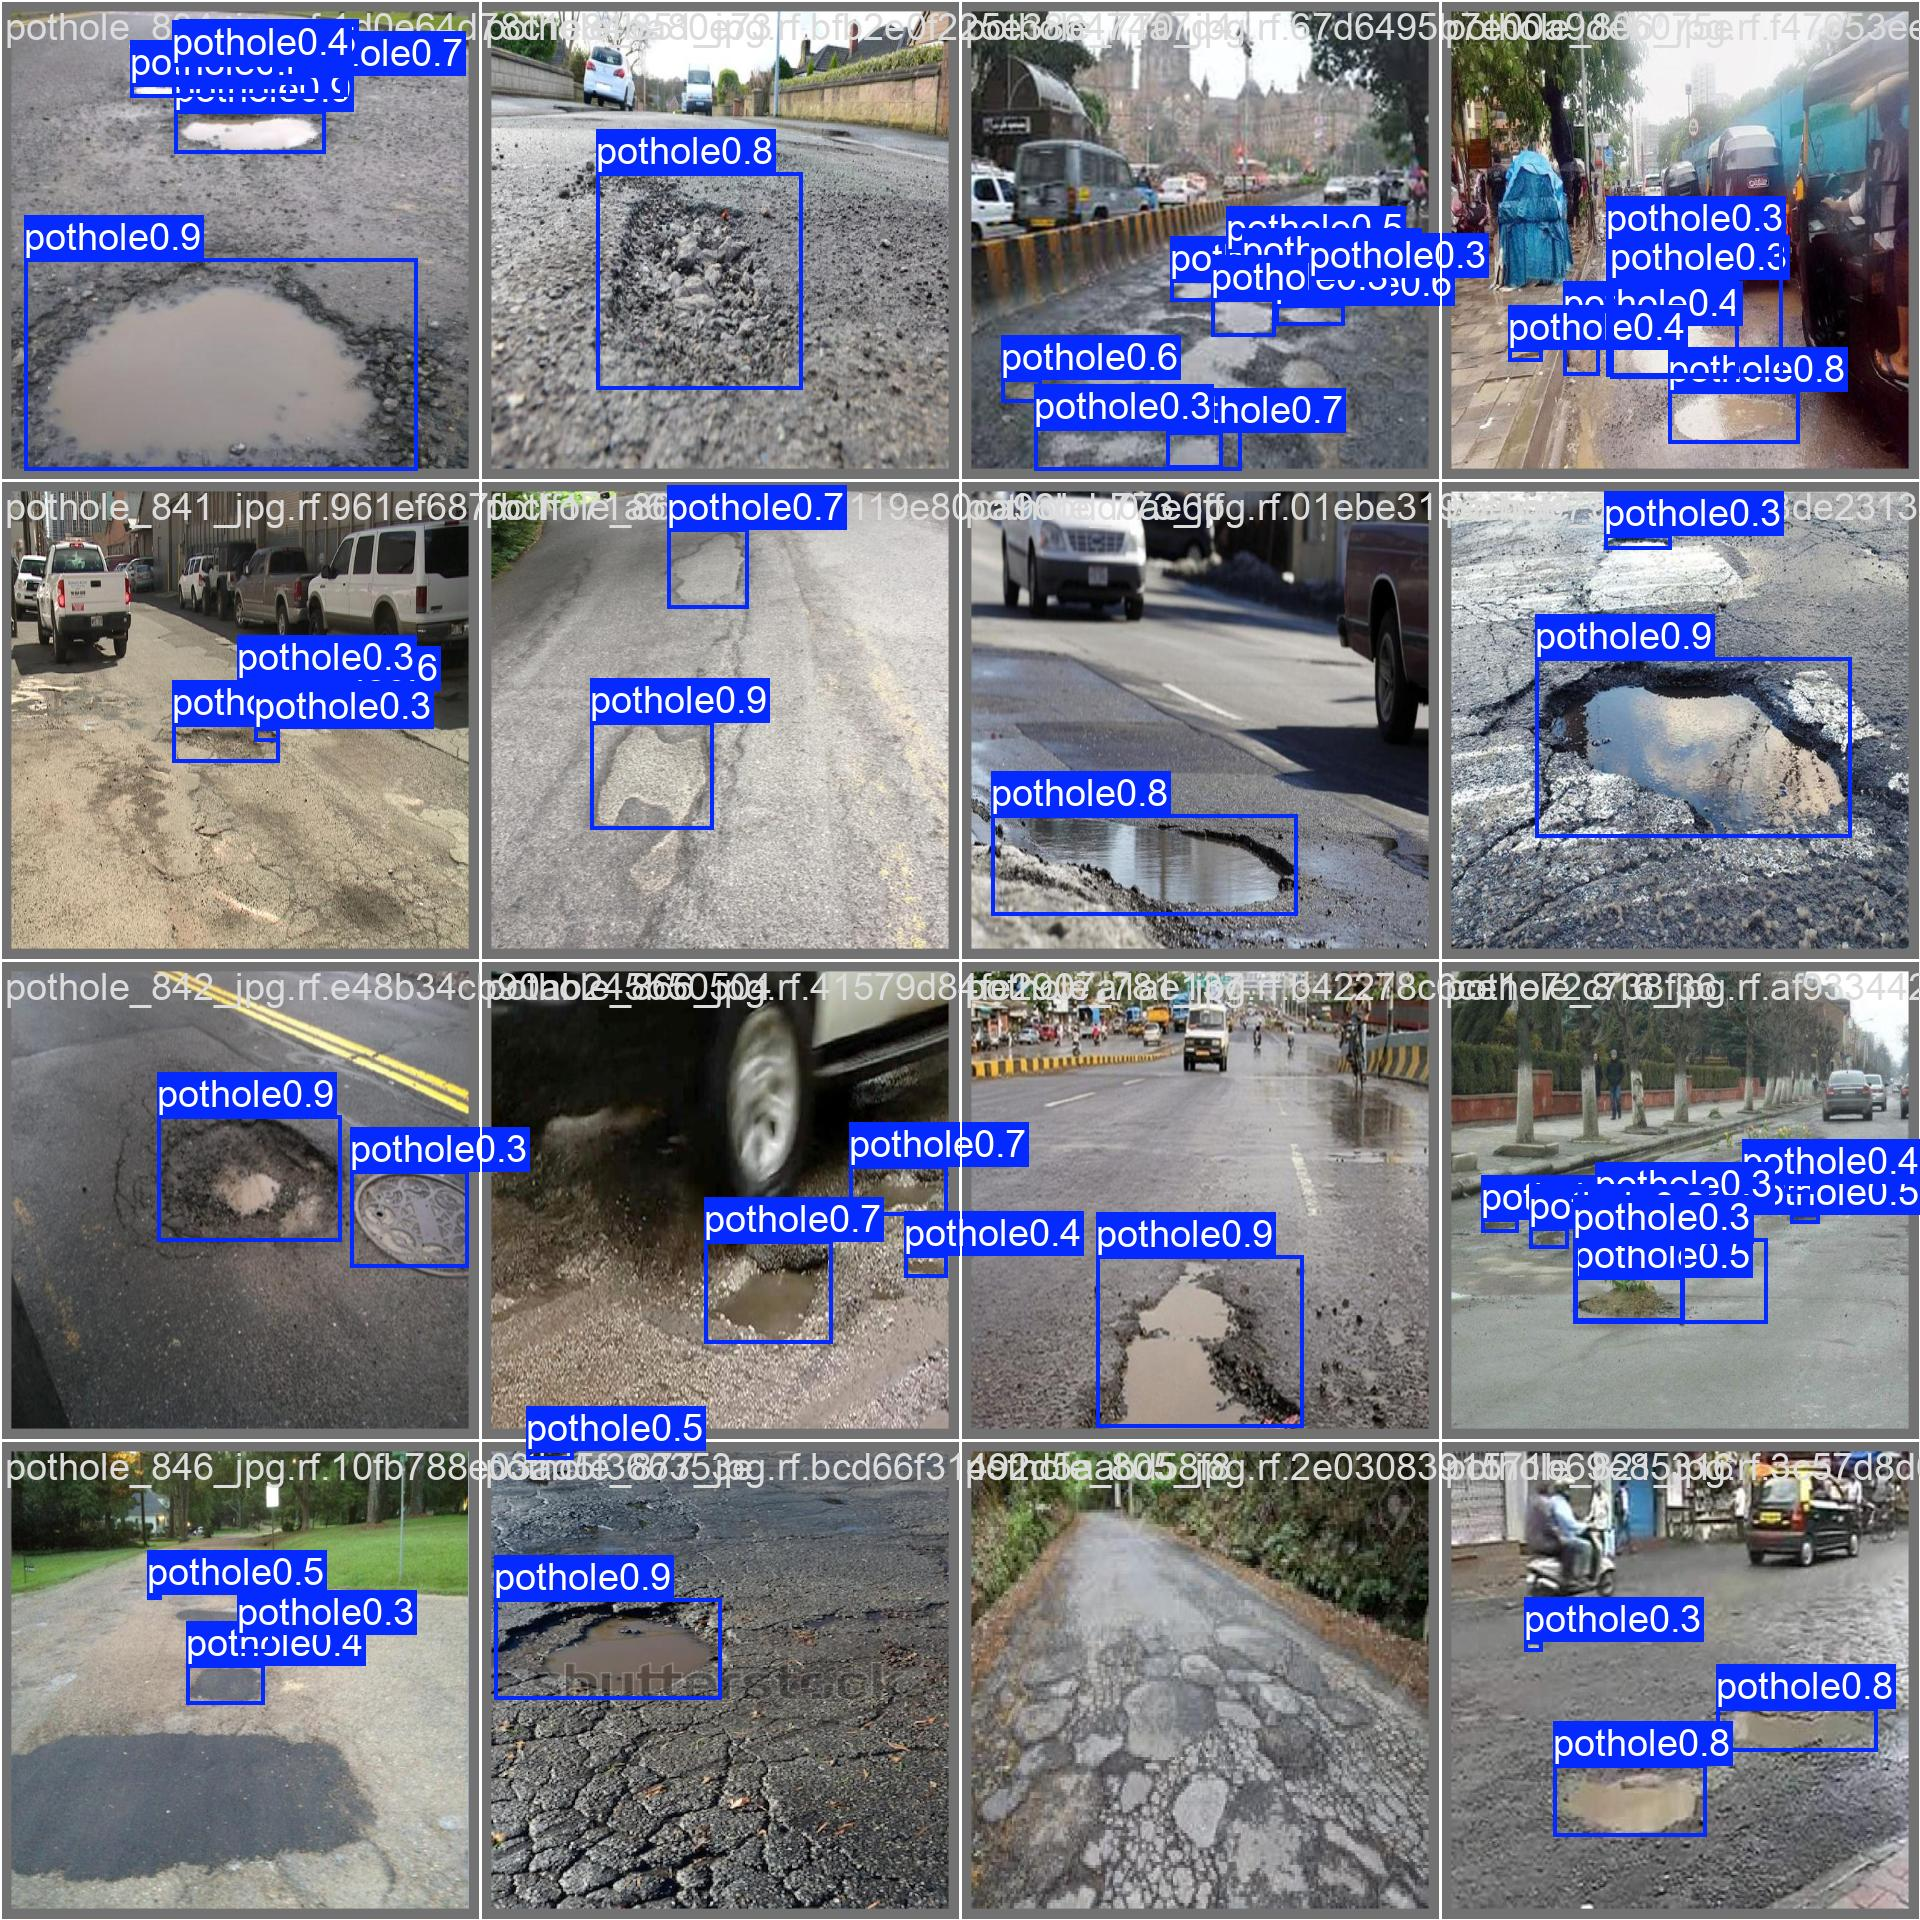

In [19]:
from IPython.display import Image, display

display(Image(filename="runs/detect/val/val_batch0_pred.jpg"))

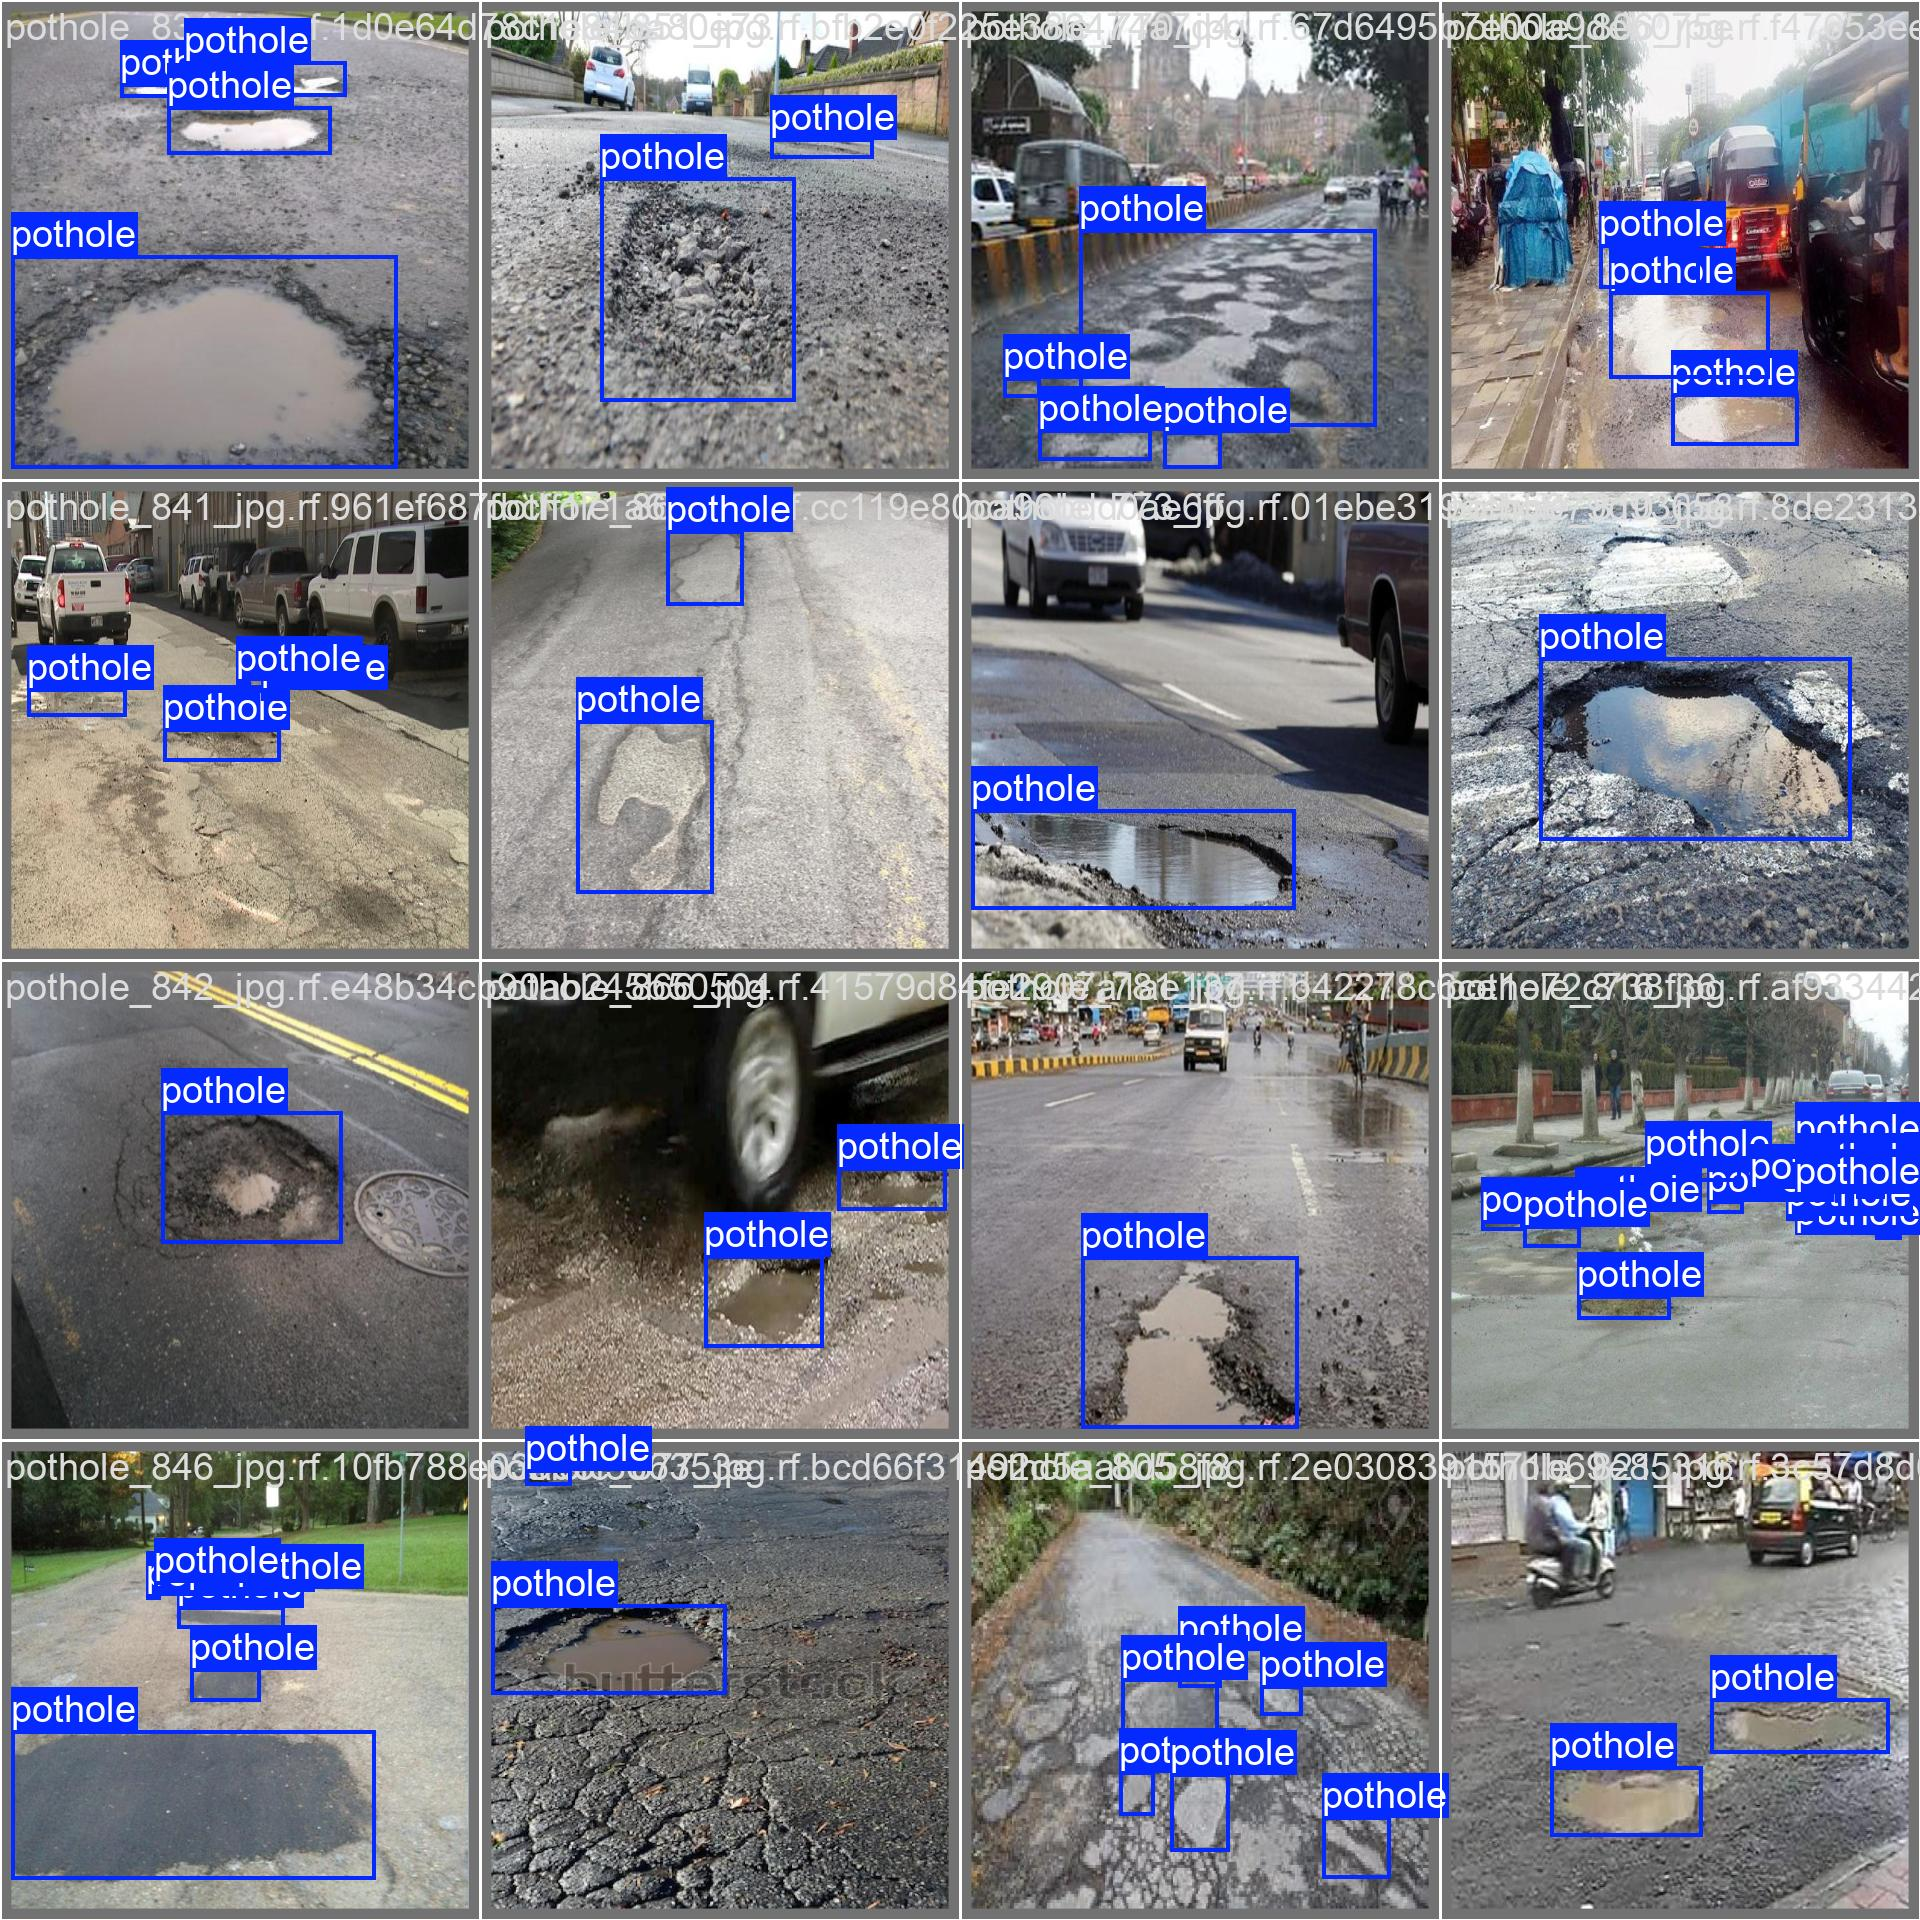

In [20]:
from IPython.display import Image, display

display(Image(filename="runs/detect/val/val_batch0_labels.jpg"))

In [21]:
print(model.ckpt_path)

None


In [22]:
from ultralytics import YOLO

best_model = YOLO("runs/detect/train/weights/best.pt")

In [23]:
results = best_model.predict(
    source="/content/smart-pothole-detection-1/test/images",
    conf=0.5,
    iou=0.5,
    save=True
)


image 1/178 /content/smart-pothole-detection-1/test/images/img-104_jpg.rf.8d62a938d5e0943bb143acd8b3488581.jpg: 640x640 2 potholes, 7.2ms
image 2/178 /content/smart-pothole-detection-1/test/images/img-111_jpg.rf.42c8e2543fe58f18a99c350470499aa3.jpg: 640x640 2 potholes, 7.2ms
image 3/178 /content/smart-pothole-detection-1/test/images/img-124_jpg.rf.6bc370793255e5f249df70adb62b59d9.jpg: 640x640 2 potholes, 7.2ms
image 4/178 /content/smart-pothole-detection-1/test/images/img-125_jpg.rf.148f6e8a367a4a6ef2ee238023caa678.jpg: 640x640 1 pothole, 7.2ms
image 5/178 /content/smart-pothole-detection-1/test/images/img-130_jpg.rf.d4a8b47a206b629493c8dfc8d591e3fd.jpg: 640x640 1 pothole, 7.2ms
image 6/178 /content/smart-pothole-detection-1/test/images/img-137_jpg.rf.e3c4c4532158578fe699dc9e1b8cfa66.jpg: 640x640 1 pothole, 7.2ms
image 7/178 /content/smart-pothole-detection-1/test/images/img-138_jpg.rf.9f8f5149b1bfd76c2c98ee07dc4fb918.jpg: 640x640 1 pothole, 7.3ms
image 8/178 /content/smart-pothole-de

In [25]:
import glob

images = glob.glob("runs/detect/predict*/*.jpg")
print(images[:5])

['runs/detect/predict-2/pa3425_jpg.rf.0a5c8db3cefca24994fa727ee75d03f3.jpg', 'runs/detect/predict-2/pa573_jpg.rf.31f305cbaf21e0b47b031f072ba55128.jpg', 'runs/detect/predict-2/img-449_jpg.rf.f53d3979f3cd3e0b35e2578cc21c21b9.jpg', 'runs/detect/predict-2/img-506_jpg.rf.a034b10cac6e3eea708b14048c7c57e1.jpg', 'runs/detect/predict-2/pa3167_jpg.rf.17156fb7d5f92c13e82906beee6f4ff6.jpg']


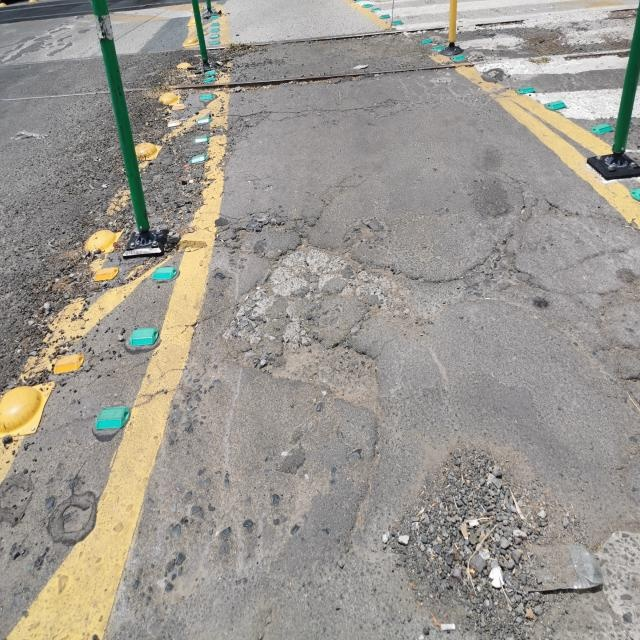

In [26]:
from IPython.display import Image, display

display(Image(filename=images[0]))

In [27]:
results = best_model.predict(
    source="/content/smart-pothole-detection-1/test/images",
    conf=0.25,
    iou=0.4,
    save=True
)


image 1/178 /content/smart-pothole-detection-1/test/images/img-104_jpg.rf.8d62a938d5e0943bb143acd8b3488581.jpg: 640x640 2 potholes, 7.9ms
image 2/178 /content/smart-pothole-detection-1/test/images/img-111_jpg.rf.42c8e2543fe58f18a99c350470499aa3.jpg: 640x640 4 potholes, 7.2ms
image 3/178 /content/smart-pothole-detection-1/test/images/img-124_jpg.rf.6bc370793255e5f249df70adb62b59d9.jpg: 640x640 2 potholes, 7.2ms
image 4/178 /content/smart-pothole-detection-1/test/images/img-125_jpg.rf.148f6e8a367a4a6ef2ee238023caa678.jpg: 640x640 1 pothole, 7.2ms
image 5/178 /content/smart-pothole-detection-1/test/images/img-130_jpg.rf.d4a8b47a206b629493c8dfc8d591e3fd.jpg: 640x640 2 potholes, 7.2ms
image 6/178 /content/smart-pothole-detection-1/test/images/img-137_jpg.rf.e3c4c4532158578fe699dc9e1b8cfa66.jpg: 640x640 1 pothole, 7.2ms
image 7/178 /content/smart-pothole-detection-1/test/images/img-138_jpg.rf.9f8f5149b1bfd76c2c98ee07dc4fb918.jpg: 640x640 1 pothole, 7.2ms
image 8/178 /content/smart-pothole-d

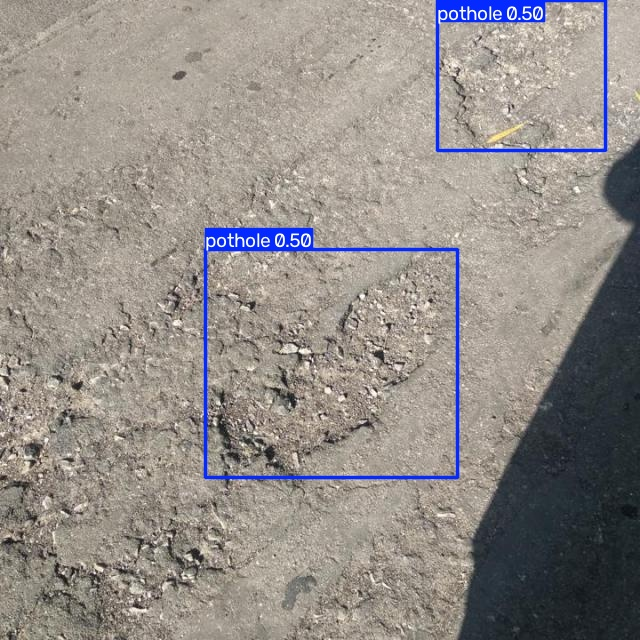

In [28]:
import glob
from IPython.display import Image, display

images = glob.glob("runs/detect/predict*/*.jpg")
display(Image(filename=images[-1]))

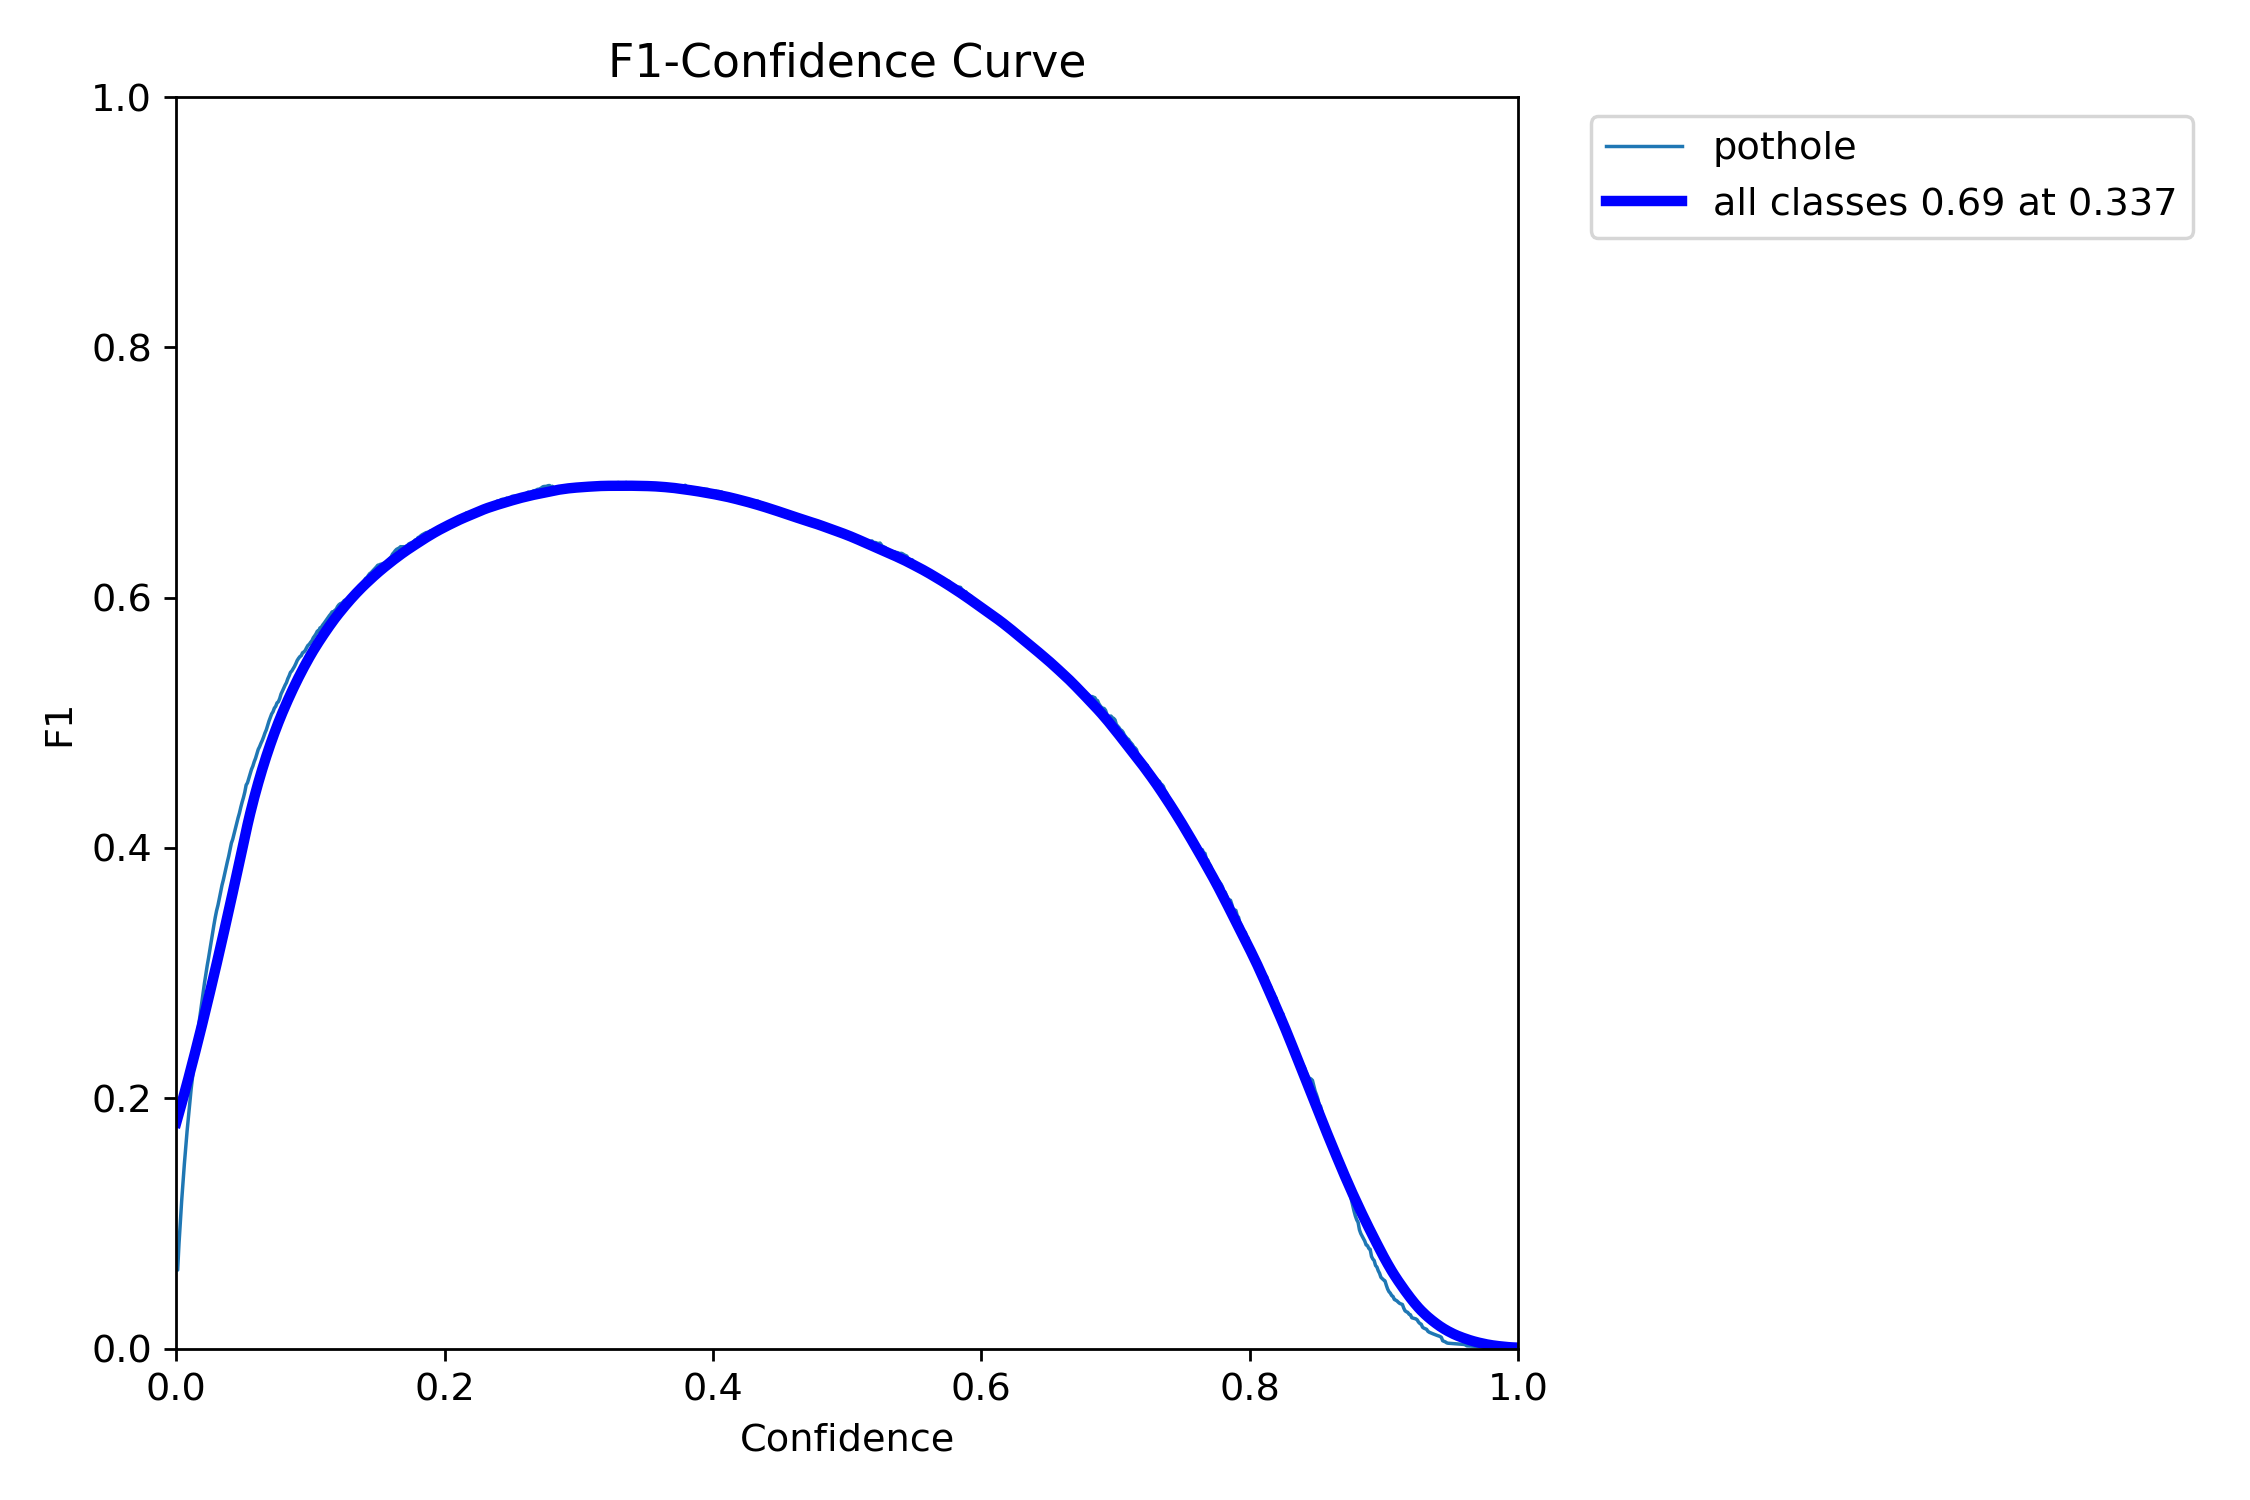

In [31]:
from IPython.display import Image, display

display(Image(filename="runs/detect/train/BoxF1_curve.png"))

In [32]:
results = best_model.predict(
    source="/content/smart-pothole-detection-1/test/images",
    conf=0.337,
    iou=0.5,
    save=True
)


image 1/178 /content/smart-pothole-detection-1/test/images/img-104_jpg.rf.8d62a938d5e0943bb143acd8b3488581.jpg: 640x640 2 potholes, 7.3ms
image 2/178 /content/smart-pothole-detection-1/test/images/img-111_jpg.rf.42c8e2543fe58f18a99c350470499aa3.jpg: 640x640 2 potholes, 7.2ms
image 3/178 /content/smart-pothole-detection-1/test/images/img-124_jpg.rf.6bc370793255e5f249df70adb62b59d9.jpg: 640x640 2 potholes, 7.5ms
image 4/178 /content/smart-pothole-detection-1/test/images/img-125_jpg.rf.148f6e8a367a4a6ef2ee238023caa678.jpg: 640x640 1 pothole, 9.8ms
image 5/178 /content/smart-pothole-detection-1/test/images/img-130_jpg.rf.d4a8b47a206b629493c8dfc8d591e3fd.jpg: 640x640 1 pothole, 7.4ms
image 6/178 /content/smart-pothole-detection-1/test/images/img-137_jpg.rf.e3c4c4532158578fe699dc9e1b8cfa66.jpg: 640x640 1 pothole, 7.2ms
image 7/178 /content/smart-pothole-detection-1/test/images/img-138_jpg.rf.9f8f5149b1bfd76c2c98ee07dc4fb918.jpg: 640x640 1 pothole, 7.2ms
image 8/178 /content/smart-pothole-de

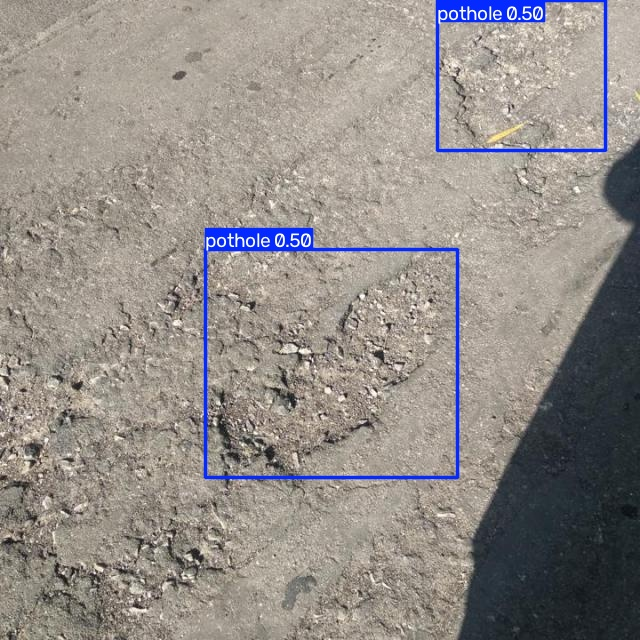

In [33]:
import glob
from IPython.display import Image, display

images = glob.glob("runs/detect/predict*/*.jpg")
display(Image(filename=images[-1]))

In [34]:
metrics = best_model.val(
    data="/content/smart-pothole-detection-1/data.yaml",
    split="test",
    conf=0.337
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2664.8±608.6 MB/s, size: 89.6 KB)
val: Scanning /content/smart-pothole-detection-1/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 2.2Kit/s 0.1s
val: New cache created: /content/smart-pothole-detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.6it/s 4.6s
                   all        178        412      0.734      0.536      0.499      0.307
Speed: 5.6ms preprocess, 5.7ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val-4
Precision: 0.7342192691029901
Recall: 0.5364077669902912
mAP50: 0.4992585180338508
mAP50-95: 0.30716561435209483


In [35]:
results = best_model.predict(
    source="/content/smart-pothole-detection-1/test/images",
    conf=0.337,
    iou=0.5,
    save=True
)


image 1/178 /content/smart-pothole-detection-1/test/images/img-104_jpg.rf.8d62a938d5e0943bb143acd8b3488581.jpg: 640x640 2 potholes, 7.9ms
image 2/178 /content/smart-pothole-detection-1/test/images/img-111_jpg.rf.42c8e2543fe58f18a99c350470499aa3.jpg: 640x640 2 potholes, 7.2ms
image 3/178 /content/smart-pothole-detection-1/test/images/img-124_jpg.rf.6bc370793255e5f249df70adb62b59d9.jpg: 640x640 2 potholes, 7.6ms
image 4/178 /content/smart-pothole-detection-1/test/images/img-125_jpg.rf.148f6e8a367a4a6ef2ee238023caa678.jpg: 640x640 1 pothole, 7.2ms
image 5/178 /content/smart-pothole-detection-1/test/images/img-130_jpg.rf.d4a8b47a206b629493c8dfc8d591e3fd.jpg: 640x640 1 pothole, 7.2ms
image 6/178 /content/smart-pothole-detection-1/test/images/img-137_jpg.rf.e3c4c4532158578fe699dc9e1b8cfa66.jpg: 640x640 1 pothole, 7.2ms
image 7/178 /content/smart-pothole-detection-1/test/images/img-138_jpg.rf.9f8f5149b1bfd76c2c98ee07dc4fb918.jpg: 640x640 1 pothole, 7.2ms
image 8/178 /content/smart-pothole-de

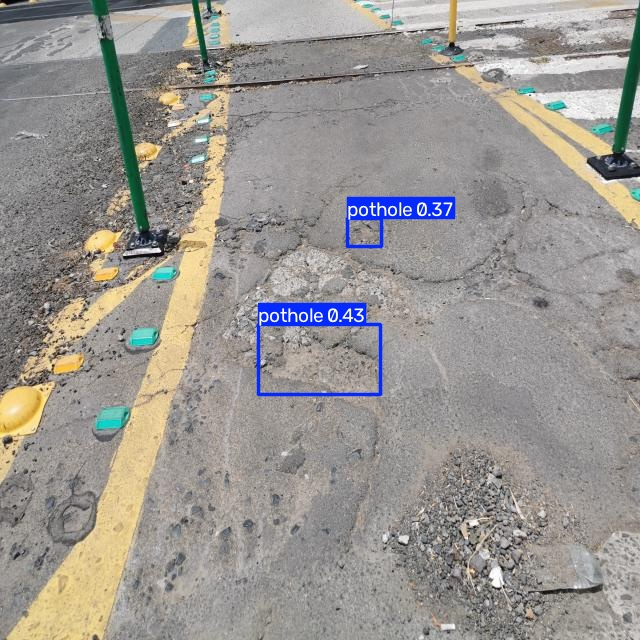

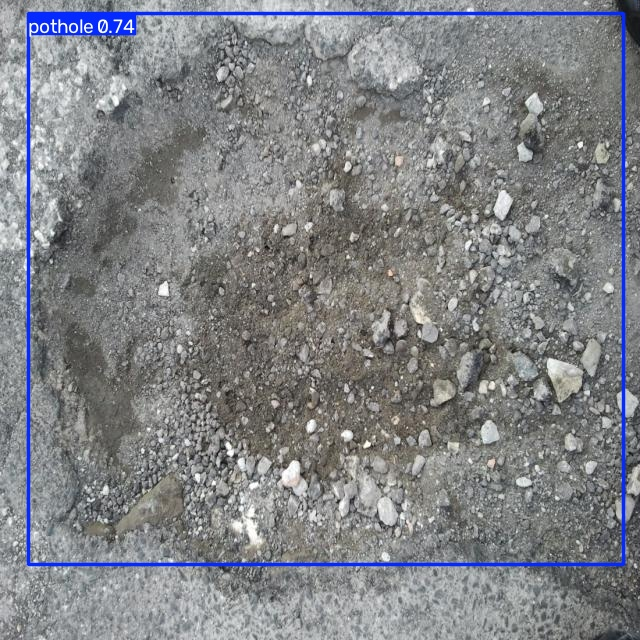

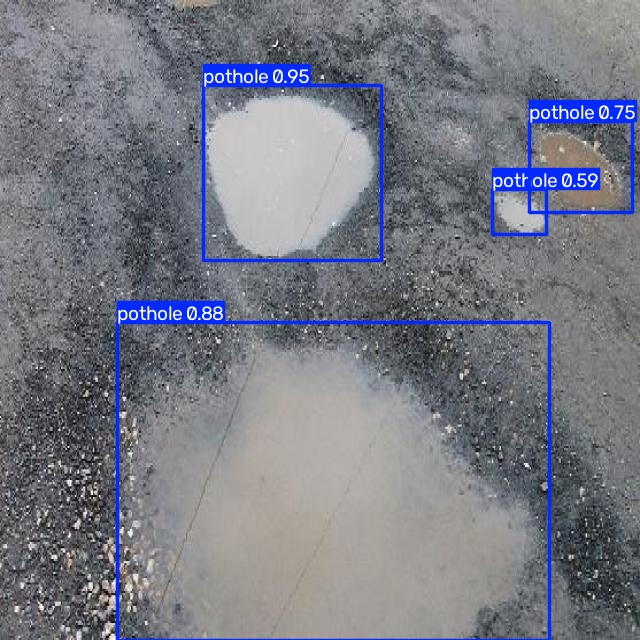

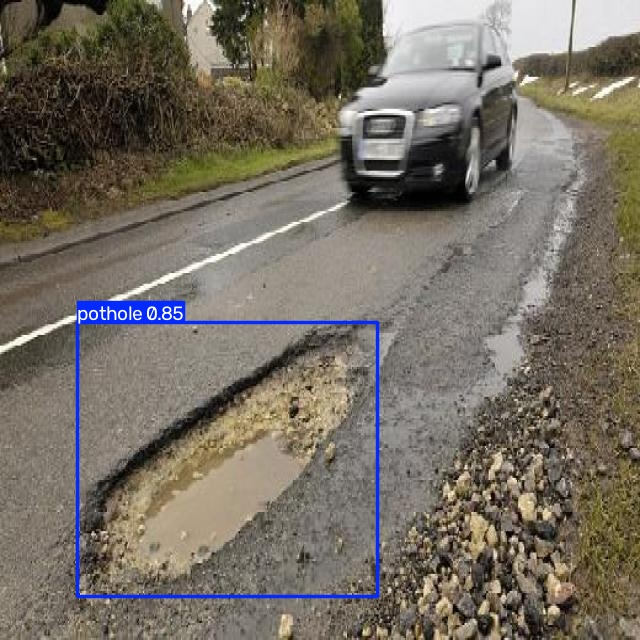

In [36]:
import glob
from IPython.display import Image, display

images = glob.glob("runs/detect/predict*/*.jpg")

for img in images[:4]:
    display(Image(filename=img))

In [37]:
modell = YOLO("yolov8n.yaml")

In [ ]:
results = modell.train(
    data="/content/smart-pothole-detection-1/data.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    patience=30,
    pretrained=False
)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smart-pothole-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, o